# ODMR fitting notebook: reference spectrum -> line centers -> B0, D, Mz

This notebook does the first calibration step for NV vector magnetometry.

Goal:
1. Fit a fully resolved ODMR spectrum with 8 hyperfine-resolved transitions.
2. Extract the 8 ODMR transition centers.
3. Pair left/right transitions by NV axis using the experimentally known assignment:
   - left side order: d1, d2, d3, d4
   - right side order: d4, d3, d2, d1
4. Use those 8 fitted line centers to estimate and then refine:
   - B0 = (Bx, By, Bz)
   - D
   - Mz = (Mz1, Mz2, Mz3, Mz4)

Conventions used here:
- Raw frequency is read in Hz.
- All fitting and Hamiltonian calculations are done in MHz.
- Plot labels may use GHz for readability.

Physical model:
- Each ODMR transition is modeled as a triplet of Lorentzians representing the 14N hyperfine structure.
- The full spectrum is fit globally.
- The fitted 8 transition centers are then used in a reduced spin-1 Hamiltonian fit.

Diamond / frame convention used in this notebook:
- {100} cut diamond
- d1, d2 = axes below the plane
- d3, d4 = axes above the plane
- left-side dip order is imposed from experiment: d1, d2, d3, d4

## 1. Imports and Constants


In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib


from scipy.signal import savgol_filter, find_peaks
from scipy.optimize import least_squares
from itertools import product
 
import fit_functions
importlib.reload(fit_functions)

from fit_functions import (
    normalize_signal,
    detect_8_transition_guesses,
    residuals_odmr_full,
    odmr_model_full,
    odmr_triplet,
    lorentzian,
)

# Constants
# -----------------------------
GAMMA_E_MHZ_PER_MT = 28.02495164   # electron gyromagnetic ratio in MHz/mT
SQRT2_OVER3 = np.sqrt(2.0 / 3.0)
ONE_OVER_SQRT3 = 1.0 / np.sqrt(3.0)

# Spin-1 matrices in the {|+1>, |0>, |-1>} basis
Sx = (1 / np.sqrt(2)) * np.array([
    [0, 1, 0],
    [1, 0, 1],
    [0, 1, 0]
], dtype=float)

Sy = (1 / np.sqrt(2)) * np.array([
    [0, -1j, 0],
    [1j, 0, -1j],
    [0, 1j, 0]
], dtype=complex)

Sz = np.array([
    [1, 0, 0],
    [0, 0, 0],
    [0, 0, -1]
], dtype=float)

Sz2 = Sz @ Sz


# NV axes in the laboratory frame
# Convention fixed to your setup:
# d1,d2 below plane, d3,d4 above plane
# -----------------------------
n_d3 = np.array([ SQRT2_OVER3,  0.0,             ONE_OVER_SQRT3])
n_d2 = np.array([ 0.0,           SQRT2_OVER3,   -ONE_OVER_SQRT3])
n_d4 = np.array([-SQRT2_OVER3,   0.0,             ONE_OVER_SQRT3])
n_d1 = np.array([ 0.0,          -SQRT2_OVER3,   -ONE_OVER_SQRT3])

NV_AXES = {
    "d1": n_d1,
    "d2": n_d2,
    "d3": n_d3,
    "d4": n_d4,
}

# Left-side order imposed by experimental assignment
LEFT_ORDER = ["d1", "d2", "d3", "d4"]
RIGHT_ORDER = ["d4", "d3", "d2", "d1"]  # mirrored around D

print("Using gamma_e =", GAMMA_E_MHZ_PER_MT, "MHz/mT")
print("Left-side order:", LEFT_ORDER)
print("Right-side order:", RIGHT_ORDER)


Using gamma_e = 28.02495164 MHz/mT
Left-side order: ['d1', 'd2', 'd3', 'd4']
Right-side order: ['d4', 'd3', 'd2', 'd1']


## 2. Load ODMR Data from CSV
Load the `ODMR_avg_99-6dBm_0mW.csv` file using pandas and inspect the data structure.

Loaded 1000 points
Frequency range [GHz]: 2.77 to 2.9698


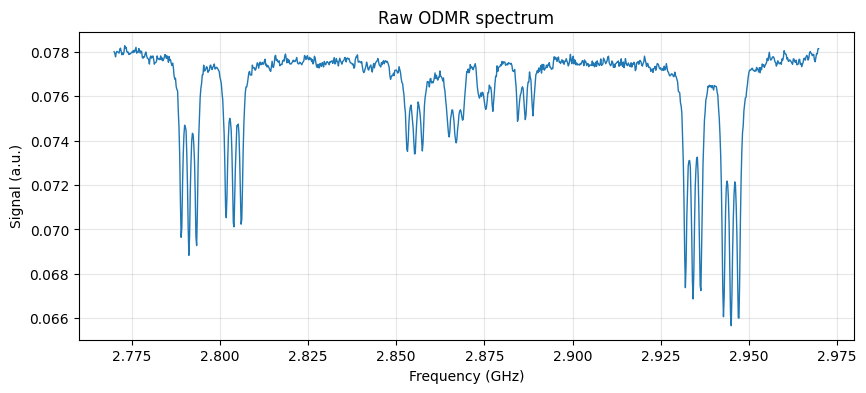

In [92]:
csv_path = "/home/vita/projects/NV_sensing/data/ODMR_avg_99-6dBm_0mW.csv"
df = pd.read_csv(csv_path, sep=r"\s+")

# Make sure we work with NumPy arrays, not pandas Series
f_hz = df["Frequency"].to_numpy(dtype=float)
y_raw = df["Pixel(95-95)"].to_numpy(dtype=float)

# Sort by frequency just in case
idx = np.argsort(f_hz)
f_hz = f_hz[idx]
y_raw = y_raw[idx]

# Units
f_mhz = f_hz / 1e6
f_ghz = f_hz / 1e9

print("Loaded", len(f_hz), "points")
print("Frequency range [GHz]:", f_ghz.min(), "to", f_ghz.max())

plt.figure(figsize=(10, 4))
plt.plot(f_ghz, y_raw, lw=1)
plt.xlabel("Frequency (GHz)")
plt.ylabel("Signal (a.u.)")
plt.title("Raw ODMR spectrum")
plt.grid(True, alpha=0.3)
plt.show()


## 3. Fit ODMR Data Using fitlorenzo Functions
Apply the fitting functions from fitlorenzo to the loaded ODMR data to obtain fit parameters.

Initial 8 center guesses [MHz]:
[2792.2 2805.  2854.2 2866.2 2874.6 2885.6 2935.2 2946. ]
len(p0) = 51
len(lb) = 51
len(ub) = 51
p0 inside bounds: True


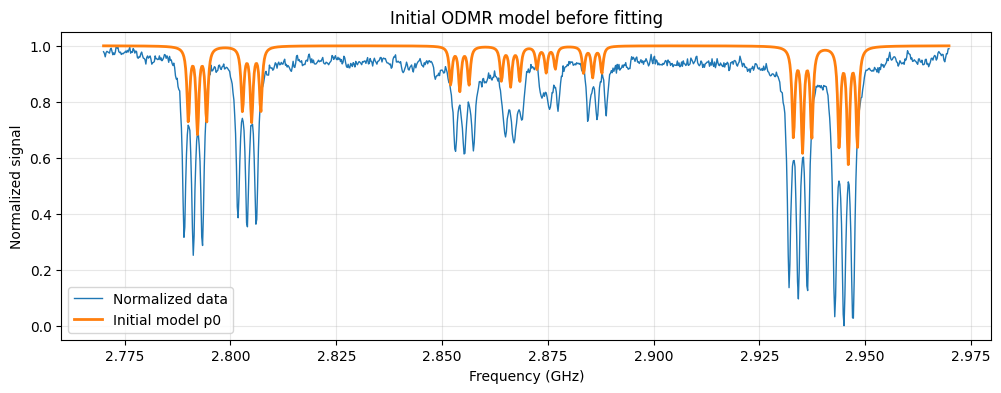

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.7335e+01                                    4.03e+01    
       1              2         5.8463e+00      1.15e+01       1.71e+00       3.80e+00    
       2              3         2.4726e+00      3.37e+00       1.73e+00       2.44e+00    
       3              4         1.5913e+00      8.81e-01       1.77e+00       3.60e+00    
       4              5         1.3400e+00      2.51e-01       2.18e+00       3.90e+00    
       5              6         4.4573e-01      8.94e-01       5.47e-01       6.64e-01    
       6              7         1.7675e-01      2.69e-01       9.85e-01       1.28e+00    
       7              8         1.2925e-01      4.75e-02       1.22e+00       4.85e-01    
       8              9         1.0079e-01      2.85e-02       5.05e-01       8.28e-02    
       9             10         9.3851e-02      6.93e-03       5.03e-01       2.15e-01    

In [95]:
# Initial guesses for the global fit
# -----------------------------
y_norm = normalize_signal(y_raw)

centers_guess, y_smooth, peak_idx, peak_prom = detect_8_transition_guesses(
    f_mhz, y_norm, smooth_window=21, polyorder=3, prominence=0.01
)
centers_guess = np.asarray(centers_guess, dtype=float)

print("Initial 8 center guesses [MHz]:")
print(np.round(centers_guess, 3))

# one hyperfine splitting guess per transition
delta_hf_guess = np.full(8, 2.16, dtype=float)

# one linewidth per transition
gamma_guesses = np.full(8, 0.8, dtype=float)

# three independent amplitudes per transition
amp_guesses = []
for c0 in centers_guess:
    mask = np.abs(f_mhz - c0) < 1.5
    local_depth = np.max(1.0 - y_norm[mask]) if np.any(mask) else 0.15

    # distribute initial amplitude roughly equally across the 3 hf lines
    a = max(local_depth, 0.05)
    amp_guesses.extend([0.35 * a, 0.40 * a, 0.35 * a])

amp_guesses = np.array(amp_guesses, dtype=float)

# baseline on centered x
b2_guess = 0.0
b1_guess = 0.0
b0_guess = 1.0

p0 = np.concatenate([
    centers_guess,      # 8
    delta_hf_guess,     # 8
    gamma_guesses,      # 8
    amp_guesses,        # 24
    [b2_guess, b1_guess, b0_guess]  # 3
])

# bounds
center_lb = centers_guess - 3.0
center_ub = centers_guess + 3.0

delta_lb = np.full(8, 1.7)
delta_ub = np.full(8, 2.5)

gamma_lb = np.full(8, 0.15)
gamma_ub = np.full(8, 2.5)

amp_lb = np.zeros(24)
amp_ub = np.full(24, 1.2)

lb = np.concatenate([
    center_lb,
    delta_lb,
    gamma_lb,
    amp_lb,
    [-1e-4, -1e-2, 0.7]
])

ub = np.concatenate([
    center_ub,
    delta_ub,
    gamma_ub,
    amp_ub,
    [1e-4, 1e-2, 1.2]
])

print("len(p0) =", len(p0))
print("len(lb) =", len(lb))
print("len(ub) =", len(ub))
print("p0 inside bounds:", np.all(p0 >= lb) and np.all(p0 <= ub))

# initial model check
y0 = odmr_model_full(f_mhz, p0)

plt.figure(figsize=(12, 4))
plt.plot(f_ghz, y_norm, label="Normalized data", lw=1)
plt.plot(f_ghz, y0, label="Initial model p0", lw=2)
plt.xlabel("Frequency (GHz)")
plt.ylabel("Normalized signal")
plt.title("Initial ODMR model before fitting")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

fit1 = least_squares(
    residuals_odmr_full,
    x0=p0,
    bounds=(lb, ub),
    args=(f_mhz, y_norm),
    method="trf",
    max_nfev=50000,
    verbose=2
)

p_fit = fit1.x
y_fit = odmr_model_full(f_mhz, p_fit)

centers_fit = np.asarray(p_fit[0:8], dtype=float)
delta_hf_fit = np.asarray(p_fit[8:16], dtype=float)
gamma_fit = np.asarray(p_fit[16:24], dtype=float)
amps_fit = np.asarray(p_fit[24:48], dtype=float).reshape(8, 3)

# sort by center for display / later pairing
order = np.argsort(centers_fit)
centers_fit = centers_fit[order]
delta_hf_fit = delta_hf_fit[order]
gamma_fit = gamma_fit[order]
amps_fit = amps_fit[order]

print("Fitted centers [MHz]:")
print(np.round(centers_fit, 4))
print("Fitted delta_hf_i [MHz]:")
print(np.round(delta_hf_fit, 4))
print("Fitted gamma_i [MHz]:")
print(np.round(gamma_fit, 4))
print("Fitted amplitudes per transition [A-, A0, A+]:")
print(np.round(amps_fit, 4))

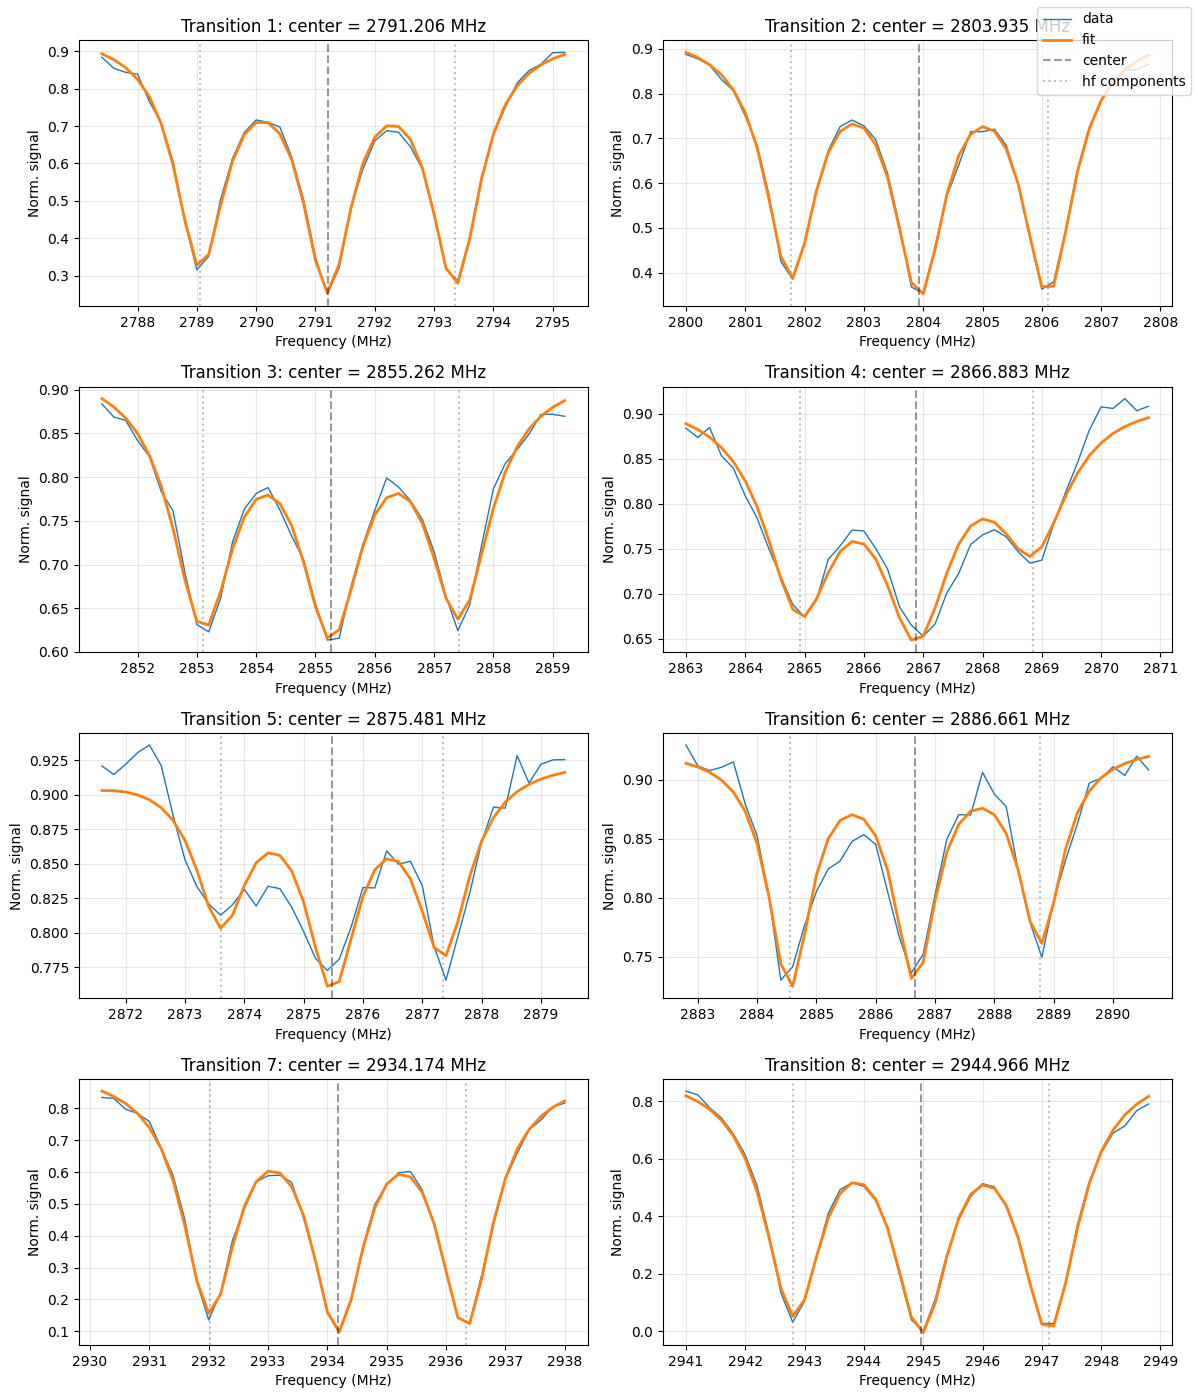

In [97]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.ravel()

window_mhz = 4.0

# Use unsorted parameter blocks for component display if needed
centers_plot = centers_fit

for i, c in enumerate(centers_plot):
    ax = axes[i]
    mask = np.abs(f_mhz - c) < window_mhz

    ax.plot(f_mhz[mask], y_norm[mask], lw=1, label="data")
    ax.plot(f_mhz[mask], y_fit[mask], lw=2, label="fit")

    ax.axvline(c, color="k", ls="--", alpha=0.4, label="center" if i == 0 else None)
    ax.axvline(c - delta_hf_fit[i], color="gray", ls=":", alpha=0.5, label="hf components" if i == 0 else None)
    ax.axvline(c + delta_hf_fit[i], color="gray", ls=":", alpha=0.5)

    ax.set_title(f"Transition {i+1}: center = {c:.3f} MHz")
    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Norm. signal")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

## 4. Plot Fitted ODMR Data
Plot the original ODMR data and the fitted curve using matplotlib for visual inspection.

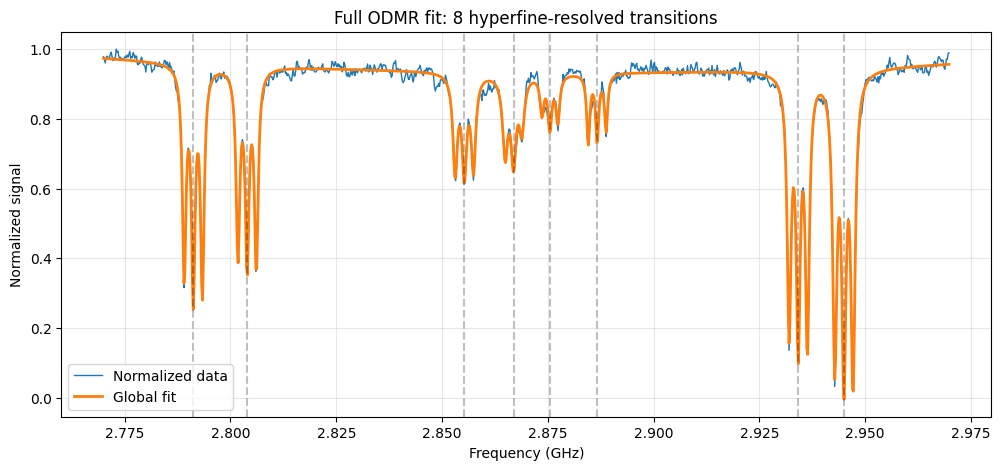

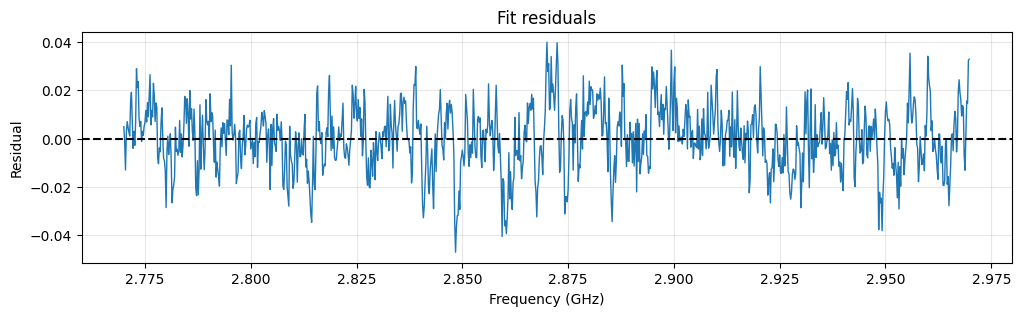

In [98]:
plt.figure(figsize=(12, 5))
plt.plot(f_ghz, y_norm, label="Normalized data", lw=1)
plt.plot(f_ghz, y_fit, label="Global fit", lw=2)

for c in centers_fit:
    plt.axvline(c / 1000.0, color="k", ls="--", alpha=0.25)

plt.xlabel("Frequency (GHz)")
plt.ylabel("Normalized signal")
plt.title("Full ODMR fit: 8 hyperfine-resolved transitions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(f_ghz, y_norm - y_fit, lw=1)
plt.axhline(0, color="k", ls="--")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Residual")
plt.title("Fit residuals")
plt.grid(True, alpha=0.3)
plt.show()

In [70]:
def pair_centers_from_8(sorted_centers_mhz):
    """
    Pair the 8 fitted transition centers using the known ODMR ordering:
    left side:  d1, d2, d3, d4
    right side: d4, d3, d2, d1

    Input:
        sorted_centers_mhz : array-like of length 8, ascending frequency order
    """
    c = np.asarray(sorted_centers_mhz, dtype=float)
    if len(c) != 8:
        raise ValueError("Need exactly 8 transition centers.")

    pairs = {
        "d1": (c[0], c[7]),
        "d2": (c[1], c[6]),
        "d3": (c[2], c[5]),
        "d4": (c[3], c[4]),
    }
    return pairs

In [71]:
pairs = pair_centers_from_8(centers_fit)

summary_rows = []
for axis in ["d1", "d2", "d3", "d4"]:
    f_l, f_u = pairs[axis]
    center_pair = 0.5 * (f_l + f_u)
    splitting = f_u - f_l
    proj_abs_mt = splitting / (2.0 * GAMMA_E_MHZ_PER_MT)

    summary_rows.append({
        "axis": axis,
        "f_left_MHz": f_l,
        "f_right_MHz": f_u,
        "pair_center_MHz": center_pair,
        "splitting_MHz": splitting,
        "|n·B0|_mT_axial_est": proj_abs_mt
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# First estimate of D from the average pair center
D0_guess_mhz = summary_df["pair_center_MHz"].mean()
print("Initial D guess [MHz] =", D0_guess_mhz)

# Mz initial guess from pair centers
Mz0_guess = {
    row["axis"]: row["pair_center_MHz"] - D0_guess_mhz
    for _, row in summary_df.iterrows()
}
print("Initial Mz guesses [MHz] =", Mz0_guess)

,axis,f_left_MHz,f_right_MHz,pair_center_MHz,splitting_MHz,|n·B0|_mT_axial_est
0,d1,2791.207028,2945.013558,2868.110293,153.806529,2.744100
1,d2,2803.945637,2934.159204,2869.052421,130.213567,2.323172
2,d3,2855.255079,2886.655792,2870.955436,31.400712,0.560228
3,d4,2866.808366,2875.449814,2871.129090,8.641449,0.154174


Initial D guess [MHz] = 2869.8118098402374
Initial Mz guesses [MHz] = {'d1': np.float64(-1.701516783232364), 'd2': np.float64(-0.7593890657562952), 'd3': np.float64(1.1436256965171196), 'd4': np.float64(1.3172801524706301)}


In [72]:
#INITIAL GESS FOR B
# Geometry matrix in the same axis order used below: d1, d2, d3, d4
N_lab = np.vstack([NV_AXES["d1"], NV_AXES["d2"], NV_AXES["d3"], NV_AXES["d4"]])

proj_abs = summary_df["|n·B0|_mT_axial_est"].to_numpy(dtype=float)

best = None
all_candidates = []

for signs in product([-1.0, 1.0], repeat=4):
    p_signed = np.array(signs) * proj_abs

    # Least-squares solution N_lab * B ≈ p_signed
    B_candidate, *_ = np.linalg.lstsq(N_lab, p_signed, rcond=None)
    residual = p_signed - N_lab @ B_candidate
    ssr = float(residual @ residual)

    all_candidates.append((signs, B_candidate, ssr))

    if best is None or ssr < best[2]:
        best = (signs, B_candidate, ssr)

best_signs, B0_guess_mt, best_ssr = best

print("Best sign pattern:", best_signs)
print("Initial B0 guess [mT] =", B0_guess_mt)
print("Initial SSR =", best_ssr)

Best sign pattern: (-1.0, 1.0, 1.0, -1.0)
Initial B0 guess [mT] = [0.43748007 3.1030576  0.35809344]
Initial SSR = 5.531062056902978e-05


In [74]:
#help me functions for H

def make_local_frame(n):
    """
    Construct a right-handed orthonormal frame (ex, ey, ez)
    with ez = n.
    """
    n = np.asarray(n, dtype=float)
    ez = n / np.linalg.norm(n)

    # Choose a reference vector not parallel to ez
    ref = np.array([0.0, 0.0, 1.0])
    if np.abs(np.dot(ref, ez)) > 0.9:
        ref = np.array([1.0, 0.0, 0.0])

    ex = np.cross(ref, ez)
    ex = ex / np.linalg.norm(ex)

    ey = np.cross(ez, ex)
    ey = ey / np.linalg.norm(ey)

    return ex, ey, ez


LOCAL_FRAMES = {axis: make_local_frame(n) for axis, n in NV_AXES.items()}


def B_lab_to_local(B_lab_mt, axis_name):
    ex, ey, ez = LOCAL_FRAMES[axis_name]
    B_lab_mt = np.asarray(B_lab_mt, dtype=float)

    return np.array([
        np.dot(B_lab_mt, ex),
        np.dot(B_lab_mt, ey),
        np.dot(B_lab_mt, ez)
    ], dtype=float)


def hamiltonian_mhz(B_lab_mt, D_mhz, Mz_mhz, axis_name):
    """
    Reduced spin-1 Hamiltonian in MHz:
        H = (D + Mz) Sz^2 + gamma_e * (Bx Sx + By Sy + Bz Sz)
    """
    Bx_loc, By_loc, Bz_loc = B_lab_to_local(B_lab_mt, axis_name)
    zeeman = GAMMA_E_MHZ_PER_MT * (Bx_loc * Sx + By_loc * Sy + Bz_loc * Sz)
    H = (D_mhz + Mz_mhz) * Sz2 + zeeman
    return H


def transition_frequencies_mhz(B_lab_mt, D_mhz, Mz_mhz, axis_name):
    """
    Return lower and upper transition frequencies in MHz.
    """
    H = hamiltonian_mhz(B_lab_mt, D_mhz, Mz_mhz, axis_name)
    evals = np.linalg.eigvalsh(H)
    evals = np.sort(np.real(evals))

    f_lower = evals[1] - evals[0]
    f_upper = evals[2] - evals[0]
    return f_lower, f_upper

In [75]:
#nonlinear dit for B0, D mz

# Measured frequencies from the spectrum fit
measured = {
    "d1": pairs["d1"],
    "d2": pairs["d2"],
    "d3": pairs["d3"],
    "d4": pairs["d4"],
}

def residuals_operating_point(theta):
    """
    theta = [Bx, By, Bz, D, Mz_d1, Mz_d2, Mz_d3, Mz_d4]
    Units:
    - B in mT
    - D, Mz in MHz
    """
    Bx, By, Bz, D_mhz, Mz_d1, Mz_d2, Mz_d3, Mz_d4 = theta
    B_lab = np.array([Bx, By, Bz], dtype=float)
    Mz_map = {
        "d1": Mz_d1,
        "d2": Mz_d2,
        "d3": Mz_d3,
        "d4": Mz_d4,
    }

    res = []
    for axis in ["d1", "d2", "d3", "d4"]:
        f_l_pred, f_u_pred = transition_frequencies_mhz(B_lab, D_mhz, Mz_map[axis], axis)
        f_l_meas, f_u_meas = measured[axis]

        res.append(f_l_pred - f_l_meas)
        res.append(f_u_pred - f_u_meas)

    return np.array(res, dtype=float)


theta0 = np.array([
    B0_guess_mt[0],
    B0_guess_mt[1],
    B0_guess_mt[2],
    D0_guess_mhz,
    Mz0_guess["d1"],
    Mz0_guess["d2"],
    Mz0_guess["d3"],
    Mz0_guess["d4"],
], dtype=float)

# Loose but physical bounds
lb = np.array([
    -50.0, -50.0, -50.0,   # Bx, By, Bz [mT]
    2800.0,                # D [MHz]
    -20.0, -20.0, -20.0, -20.0  # Mz_i [MHz]
])

ub = np.array([
     50.0,  50.0,  50.0,
    2940.0,
     20.0,  20.0,  20.0,  20.0
])

fit2 = least_squares(
    residuals_operating_point,
    x0=theta0,
    bounds=(lb, ub),
    method="trf",
    max_nfev=20000,
    verbose=2
)

theta_fit = fit2.x
Bx0, By0, Bz0, D_fit_mhz, Mz1_fit, Mz2_fit, Mz3_fit, Mz4_fit = theta_fit

print("\nRefined operating point:")
print(f"B0 [mT] = ({Bx0:.6f}, {By0:.6f}, {Bz0:.6f})")
print(f"D  [MHz] = {D_fit_mhz:.6f}")
print(f"Mz [MHz] = d1:{Mz1_fit:.6f}, d2:{Mz2_fit:.6f}, d3:{Mz3_fit:.6f}, d4:{Mz4_fit:.6f}")
print("Residual norm [MHz] =", np.linalg.norm(fit2.fun))

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.6674e+01                                    2.39e+03    
       1              2         1.5070e-01      3.65e+01       3.40e+00       5.10e+01    
       2              3         1.4568e-02      1.36e-01       3.79e-01       1.24e-01    
       3              4         1.4565e-02      3.77e-06       1.98e-02       2.68e-03    
       4              9         1.4565e-02      2.16e-11       5.39e-02       3.30e-03    
       5             15         1.4565e-02      0.00e+00       0.00e+00       3.30e-03    
`xtol` termination condition is satisfied.
Function evaluations 15, initial cost 3.6674e+01, final cost 1.4565e-02, first-order optimality 3.30e-03.

Refined operating point:
B0 [mT] = (0.431545, 3.103493, 0.360772)
D  [MHz] = 2867.186513
Mz [MHz] = d1:-0.074347, d2:0.000653, d3:-0.186213, d4:-0.132792
Residual norm [MHz] = 0.17067318638278425


In [76]:
#compare measured vs calculated H

Mz_fit_map = {"d1": Mz1_fit, "d2": Mz2_fit, "d3": Mz3_fit, "d4": Mz4_fit}
B_fit = np.array([Bx0, By0, Bz0], dtype=float)

rows = []
for axis in ["d1", "d2", "d3", "d4"]:
    f_l_meas, f_u_meas = measured[axis]
    f_l_pred, f_u_pred = transition_frequencies_mhz(B_fit, D_fit_mhz, Mz_fit_map[axis], axis)

    rows.append({
        "axis": axis,
        "f_left_meas_MHz": f_l_meas,
        "f_left_pred_MHz": f_l_pred,
        "left_err_kHz": 1e3 * (f_l_pred - f_l_meas),
        "f_right_meas_MHz": f_u_meas,
        "f_right_pred_MHz": f_u_pred,
        "right_err_kHz": 1e3 * (f_u_pred - f_u_meas),
        "pair_center_MHz": 0.5 * (f_l_meas + f_u_meas),
        "Mz_fit_MHz": Mz_fit_map[axis]
    })

compare_df = pd.DataFrame(rows)
display(compare_df)

,axis,f_left_meas_MHz,f_left_pred_MHz,left_err_kHz,f_right_meas_MHz,f_right_pred_MHz,right_err_kHz,pair_center_MHz,Mz_fit_MHz
0,d1,2791.207028,2791.266137,59.108522,2945.013558,2944.954448,-59.109293,2868.110293,-0.074347
1,d2,2803.945637,2803.885953,-59.683968,2934.159204,2934.218887,59.682186,2869.052421,0.000653
2,d3,2855.255079,2855.195326,-59.753078,2886.655792,2886.715550,59.757891,2870.955436,-0.186213
3,d4,2866.808366,2866.871110,62.744189,2875.449814,2875.387051,-62.763064,2871.129090,-0.132792


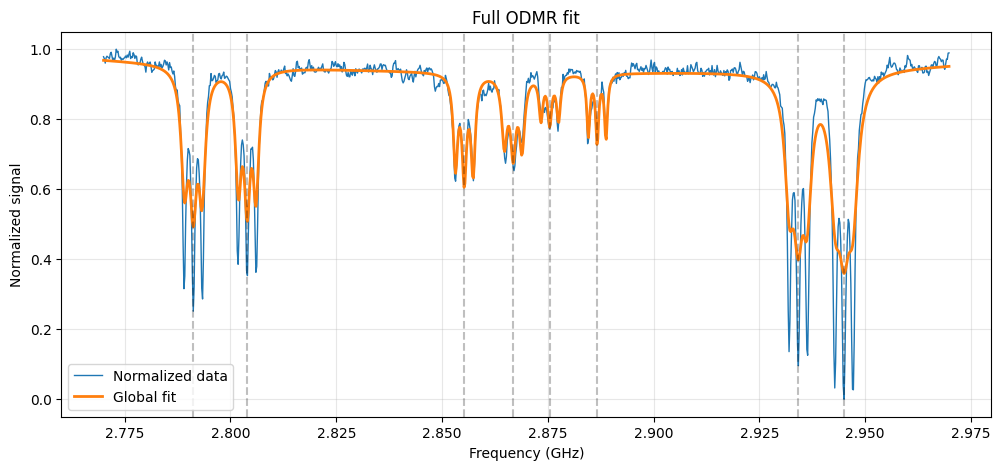

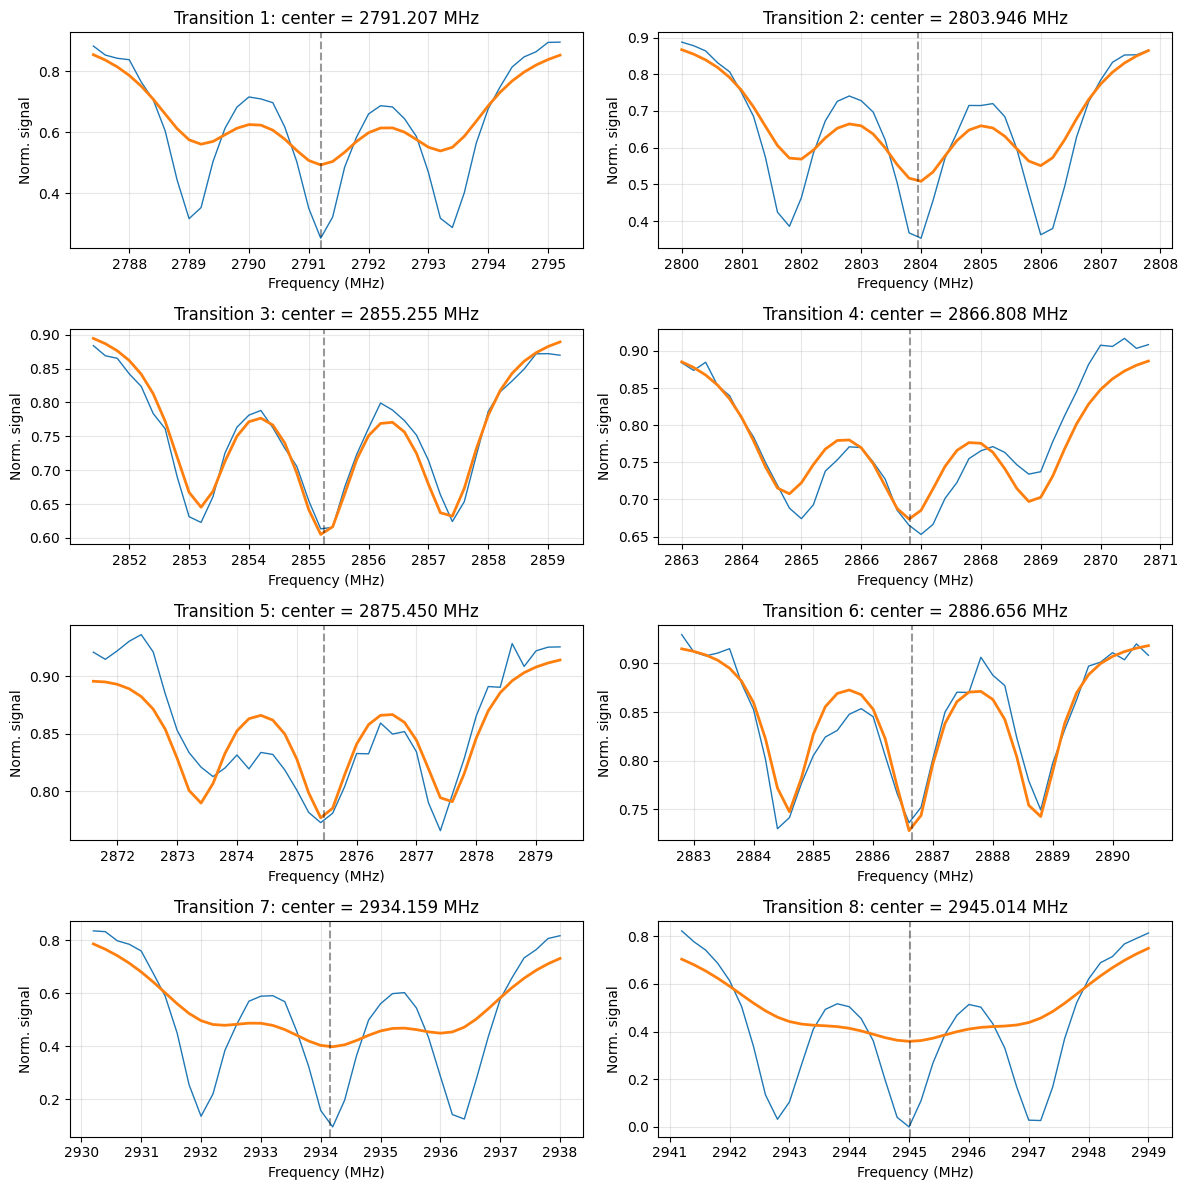

In [77]:
plt.figure(figsize=(12, 5))
plt.plot(f_ghz, y_norm, label="Normalized data", lw=1)
plt.plot(f_ghz, y_fit, label="Global fit", lw=2)

for c in centers_fit:
    plt.axvline(c / 1000.0, color="k", ls="--", alpha=0.25)

plt.xlabel("Frequency (GHz)")
plt.ylabel("Normalized signal")
plt.title("Full ODMR fit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Zoom around each fitted ODMR transition
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.ravel()

window_mhz = 4.0

for i, c in enumerate(centers_fit):
    ax = axes[i]
    mask = np.abs(f_mhz - c) < window_mhz

    ax.plot(f_mhz[mask], y_norm[mask], lw=1, label="data")
    ax.plot(f_mhz[mask], y_fit[mask], lw=2, label="fit")
    ax.axvline(c, color="k", ls="--", alpha=0.4)

    ax.set_title(f"Transition {i+1}: center = {c:.3f} MHz")
    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Norm. signal")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

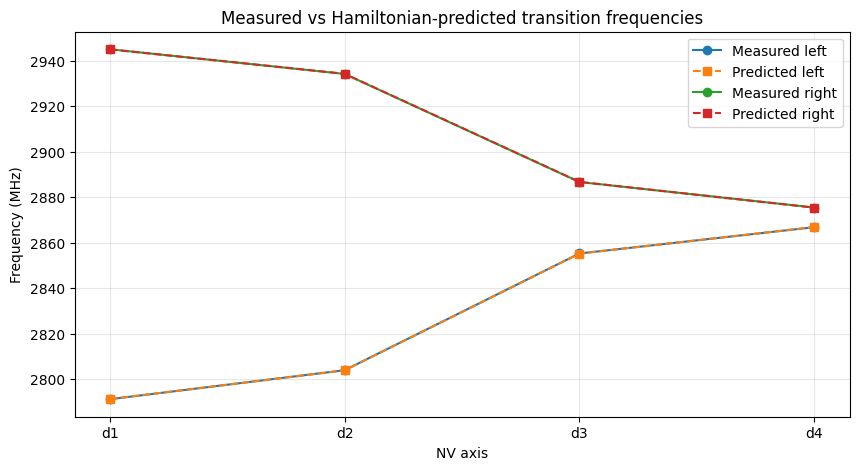

In [78]:
axes_order = ["d1", "d2", "d3", "d4"]

meas_left = []
pred_left = []
meas_right = []
pred_right = []

for axis in axes_order:
    f_l_meas, f_u_meas = measured[axis]
    f_l_pred, f_u_pred = transition_frequencies_mhz(B_fit, D_fit_mhz, Mz_fit_map[axis], axis)

    meas_left.append(f_l_meas)
    pred_left.append(f_l_pred)
    meas_right.append(f_u_meas)
    pred_right.append(f_u_pred)

x = np.arange(len(axes_order))

plt.figure(figsize=(10, 5))
plt.plot(x, meas_left, "o-", label="Measured left")
plt.plot(x, pred_left, "s--", label="Predicted left")
plt.plot(x, meas_right, "o-", label="Measured right")
plt.plot(x, pred_right, "s--", label="Predicted right")

plt.xticks(x, axes_order)
plt.ylabel("Frequency (MHz)")
plt.xlabel("NV axis")
plt.title("Measured vs Hamiltonian-predicted transition frequencies")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

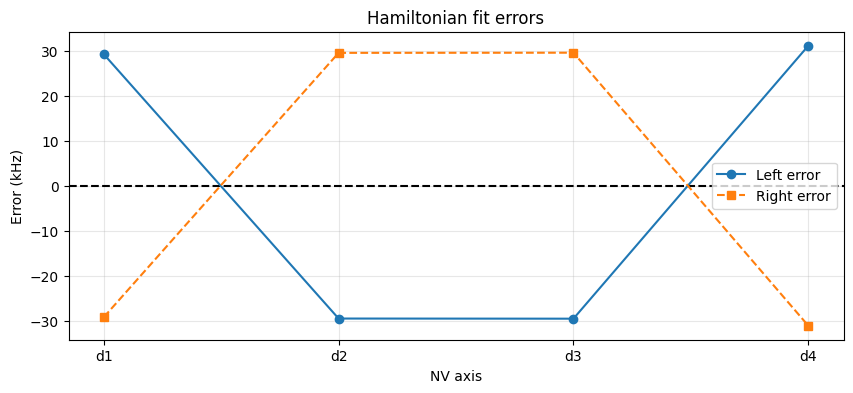

In [59]:
left_err_khz = []
right_err_khz = []

for axis in axes_order:
    f_l_meas, f_u_meas = measured[axis]
    f_l_pred, f_u_pred = transition_frequencies_mhz(B_fit, D_fit_mhz, Mz_fit_map[axis], axis)

    left_err_khz.append(1e3 * (f_l_pred - f_l_meas))
    right_err_khz.append(1e3 * (f_u_pred - f_u_meas))

plt.figure(figsize=(10, 4))
plt.axhline(0, color="k", ls="--")
plt.plot(x, left_err_khz, "o-", label="Left error")
plt.plot(x, right_err_khz, "s--", label="Right error")
plt.xticks(x, axes_order)
plt.ylabel("Error (kHz)")
plt.xlabel("NV axis")
plt.title("Hamiltonian fit errors")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

results_df.to_csv("odmr_reference_fit_summary.csv", index=False)
print("Saved: odmr_reference_fit_summary.csv")
display(results_df)